# DETR Baseline — Corrected & Complete

A working DETR training pipeline using PyTorch's `nn.Transformer`.

**What's fixed vs the original notebook:**
- `tgt = query_embed` (not zeros) so decoder queries have identity
- Removed erroneous `hs = hs + query_embed` double-add
- Added `memory_key_padding_mask` so decoder ignores encoder padding
- Gradient clipping (`max_norm=0.1`) to stop exploding gradients
- Fixed warmup iterations (was 1000 for a 50-step/epoch dataset)
- Image resizing before padding for consistent feature map sizes
- Train/Val split, validation loop, loss curves, and inference

In [1]:
import json
import os
import math
import random
import shutil

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models
from torchvision.ops import generalized_box_iou
from scipy.optimize import linear_sum_assignment

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


Using device: cuda


## Step 1: Dataset — COCO Mini

Run the cell below only once to create the 100-image subset.
If you already have `coco_mini/` skip to the Dataset class.

In [2]:
# ── Run once to create the mini dataset ──────────────────────────────────────
# Adjust paths to your local COCO download
SRC_IMAGES      = r'c:\Projects\DETR from srcatch\val2017'
SRC_ANNOTATIONS = r'c:\Projects\DETR from srcatch\val2017_annotations\annotations\instances_val2017.json'
DST_BASE        = 'coco_mini'
DST_IMAGES      = os.path.join(DST_BASE, 'images')
DST_ANNOTATIONS = os.path.join(DST_BASE, 'annotations.json')

os.makedirs(DST_IMAGES, exist_ok=True)

with open(SRC_ANNOTATIONS) as f:
    ann = json.load(f)

selected      = ann['images'][:100]
selected_ids  = {img['id'] for img in selected}
filtered_anns = [a for a in ann['annotations'] if a['image_id'] in selected_ids]

for img in selected:
    src = os.path.join(SRC_IMAGES, img['file_name'])
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(DST_IMAGES, img['file_name']))

with open(DST_ANNOTATIONS, 'w') as f:
    json.dump({'images': selected, 'annotations': filtered_anns,
               'categories': ann['categories']}, f)

print(f"Done: {len(selected)} images, {len(filtered_anns)} annotations")


Done: 100 images, 658 annotations


## Step 2: Dataset & DataLoader

**Key change from original**: images are now resized to a fixed `IMG_SIZE` before padding.
Variable-size batches were causing the encoder sequence to be huge and inconsistent,
which made learning noisy and slow.

In [3]:
IMG_SIZE = 480   # resize longest edge to this before padding
                 # keeping it fixed makes feature map sizes predictable

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


class CocoMiniDataset(Dataset):
    def __init__(self, annotation_file, image_dir, img_size=IMG_SIZE):
        with open(annotation_file) as f:
            coco = json.load(f)

        self.image_dir = image_dir
        self.img_size  = img_size

        self.id_to_image   = {img['id']: img for img in coco['images']}
        self.image_to_anns = {}
        for ann in coco['annotations']:
            self.image_to_anns.setdefault(ann['image_id'], []).append(ann)

        self.image_ids = list(self.image_to_anns.keys())

        # Remap sparse COCO category IDs → dense 0-based indices
        cat_ids = sorted({cat['id'] for cat in coco['categories']})
        self.cat_id_to_idx = {cid: i for i, cid in enumerate(cat_ids)}
        self.num_classes   = len(cat_ids)
        print(f"Dataset: {len(self.image_ids)} images, {self.num_classes} categories")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id   = self.image_ids[idx]
        image_info = self.id_to_image[image_id]
        anns       = self.image_to_anns[image_id]

        # ── Load & resize image ───────────────────────────────────────────────
        img_path = os.path.join(self.image_dir, image_info['file_name'])
        image    = cv2.imread(img_path)
        image    = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        orig_h, orig_w = image.shape[:2]

        # Resize so the longest edge = IMG_SIZE, preserving aspect ratio
        scale  = self.img_size / max(orig_h, orig_w)
        new_h  = int(orig_h * scale)
        new_w  = int(orig_w * scale)
        image  = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

        # Normalise to float and apply ImageNet stats
        image = torch.tensor(image / 255.0, dtype=torch.float32).permute(2, 0, 1)
        image = (image - IMAGENET_MEAN) / IMAGENET_STD

        # ── Boxes & labels ────────────────────────────────────────────────────
        boxes, labels = [], []
        for ann in anns:
            x, y, bw, bh = ann['bbox']
            # Convert COCO [x,y,w,h] pixel coords → DETR [cx,cy,w,h] normalised
            cx = (x + 0.5 * bw) / orig_w   # normalise against ORIGINAL size
            cy = (y + 0.5 * bh) / orig_h   # (the normalised coords are scale-invariant)
            nw = bw / orig_w
            nh = bh / orig_h

            # Clamp to [0,1] just in case of annotation noise
            cx, cy, nw, nh = (max(0., min(1., v)) for v in (cx, cy, nw, nh))
            if nw > 0 and nh > 0:           # skip degenerate boxes
                boxes.append([cx, cy, nw, nh])
                labels.append(self.cat_id_to_idx[ann['category_id']])

        boxes  = torch.tensor(boxes,  dtype=torch.float32) if boxes  else torch.zeros((0, 4))
        labels = torch.tensor(labels, dtype=torch.long)    if labels else torch.zeros((0,), dtype=torch.long)

        return image, {'boxes': boxes, 'labels': labels}


def collate_fn(batch):
    """Pad images in a batch to the same spatial size and build a boolean padding mask."""
    images  = [item[0] for item in batch]
    targets = [item[1] for item in batch]

    max_h = max(img.shape[1] for img in images)
    max_w = max(img.shape[2] for img in images)

    padded_images, masks = [], []
    for img in images:
        c, h, w = img.shape
        padded = F.pad(img, (0, max_w - w, 0, max_h - h))   # pad right & bottom
        padded_images.append(padded)

        # mask: True = padded region (transformer will ignore these positions)
        mask = torch.zeros((max_h, max_w), dtype=torch.bool)
        mask[h:, :] = True
        mask[:, w:] = True
        masks.append(mask)

    return torch.stack(padded_images), torch.stack(masks), targets


# ── Build dataset and split 80% train / 20% val ──────────────────────────────
full_dataset = CocoMiniDataset('coco_mini/annotations.json', 'coco_mini/images')
NUM_CLASSES  = full_dataset.num_classes

all_indices    = list(range(len(full_dataset)))
random.seed(42)
random.shuffle(all_indices)
split          = int(0.8 * len(all_indices))
train_indices  = all_indices[:split]
val_indices    = all_indices[split:]

train_dataset  = Subset(full_dataset, train_indices)
val_dataset    = Subset(full_dataset, val_indices)

BATCH_SIZE     = 2
train_loader   = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader     = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_dataset)} images ({len(train_loader)} batches)")
print(f"Val  : {len(val_dataset)}   images ({len(val_loader)} batches)")


Dataset: 98 images, 80 categories
Train: 78 images (39 batches)
Val  : 20   images (10 batches)


## Step 3: 2D Sinusoidal Positional Encoding

This is unchanged from your original — it was correct.

In [4]:
class PositionalEncoding2D(nn.Module):
    """
    Creates a 2D sinusoidal positional encoding for the feature map.

    DETR splits d_model in half: the first half encodes the Y position
    of each spatial cell, the second half encodes the X position.
    This gives every (row, col) location a unique, fixed embedding that
    the transformer can use to reason about spatial relationships.
    """
    def __init__(self, d_model=256, temperature=10000):
        super().__init__()
        self.d_model      = d_model
        self.temperature  = temperature
        self.num_pos_feats = d_model // 2   # 128 dims for Y, 128 for X

    def forward(self, x):
        b, c, h, w = x.shape
        device = x.device

        y_embed = torch.arange(1, h + 1, device=device, dtype=torch.float32)
        x_embed = torch.arange(1, w + 1, device=device, dtype=torch.float32)

        # Frequency terms: shape (num_pos_feats,)
        dim_t = torch.arange(self.num_pos_feats, device=device, dtype=torch.float32)
        dim_t = self.temperature ** (2 * (dim_t // 2) / self.num_pos_feats)

        pos_y = y_embed[:, None] / dim_t   # (H, num_pos_feats)
        pos_x = x_embed[:, None] / dim_t   # (W, num_pos_feats)

        # Even indices → sin, odd indices → cos
        pos_y = torch.stack((pos_y[:, 0::2].sin(), pos_y[:, 1::2].cos()), dim=2).flatten(1)
        pos_x = torch.stack((pos_x[:, 0::2].sin(), pos_x[:, 1::2].cos()), dim=2).flatten(1)

        # Broadcast: each row gets the same Y encoding; each col gets the same X encoding
        pos_y = pos_y.view(h, 1, self.num_pos_feats).expand(h, w, -1)
        pos_x = pos_x.view(1, w, self.num_pos_feats).expand(h, -1, -1)

        # Concatenate Y and X halves → shape (B, d_model, H, W)
        pos = torch.cat([pos_y, pos_x], dim=2).permute(2, 0, 1).unsqueeze(0).expand(b, -1, -1, -1)
        return pos


## Step 4: DETR Model

**Three bugs fixed here** compared to your original:

1. `tgt = query_embed` — the object queries are the decoder input, not zeros.
2. Removed `hs = hs + query_embed` — query embeddings were being double-added.
3. `memory_key_padding_mask=mask` — decoder cross-attention now ignores padded encoder positions.

In [5]:
class DETR(nn.Module):
    def __init__(self, num_classes, num_queries=100, d_model=256,
                 num_encoder_layers=3, num_decoder_layers=3, dropout=0.1):
        super().__init__()
        self.d_model     = d_model
        self.num_queries = num_queries

        # ── Backbone: ResNet-50 without the final avg-pool and FC ─────────────
        backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])
        backbone_out_channels = list(list(self.backbone.children())[-1])[-1].bn3.num_features

        # ── 1x1 conv to project backbone output → d_model dimensions ─────────
        self.input_proj = nn.Conv2d(backbone_out_channels, d_model, kernel_size=1)

        # ── 2D positional encoding ────────────────────────────────────────────
        self.pe = PositionalEncoding2D(d_model)

        # ── Transformer: encoder + decoder ───────────────────────────────────
        self.transformer = nn.Transformer(
            d_model          = d_model,
            nhead            = 8,
            num_encoder_layers = num_encoder_layers,
            num_decoder_layers = num_decoder_layers,
            dim_feedforward  = 2048,
            dropout          = dropout,
            batch_first      = False   # (seq, batch, dim) convention
        )

        # ── Learned object queries — one per detection slot ───────────────────
        # Each query is a learnable vector that the decoder will specialise into
        # detecting a particular object (or outputting 'no object').
        self.object_queries = nn.Parameter(torch.empty(num_queries, d_model))
        nn.init.xavier_uniform_(self.object_queries)

        # ── Prediction heads ──────────────────────────────────────────────────
        self.class_head = nn.Linear(d_model, num_classes + 1)   # +1 for background
        self.bbox_head  = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 4),
            nn.Sigmoid()   # ensures output is in [0,1] for normalised boxes
        )

    def forward(self, images, mask):
        # images: (B, 3, H, W),  mask: (B, H, W) — True where padded

        # ── Backbone + projection ─────────────────────────────────────────────
        features = self.backbone(images)                          # (B, 2048, H', W')
        features = self.input_proj(features)                      # (B, d_model, H', W')
        B, C, H, W = features.shape

        # ── Add 2D positional encoding to the feature map ─────────────────────
        pos  = self.pe(features)                                  # (B, d_model, H', W')
        src  = features + pos                                     # (B, d_model, H', W')

        # ── Flatten spatial dims and permute for nn.Transformer ───────────────
        # nn.Transformer expects (seq_len, batch, d_model) when batch_first=False
        src  = src.flatten(2).permute(2, 0, 1)                   # (H'*W', B, d_model)

        # ── Resize padding mask to match feature map spatial size ─────────────
        src_mask = F.interpolate(
            mask.unsqueeze(1).float(), size=(H, W), mode='nearest'
        ).squeeze(1).bool().flatten(1)                            # (B, H'*W')

        # ── Object queries as decoder input ───────────────────────────────────
        # BUG FIX 1: tgt = query_embed (expanded to batch), NOT zeros.
        # If tgt were all zeros, every query would be identical going in —
        # the transformer has nothing to differentiate them with except
        # positional info, and we have none. Learning stalls completely.
        tgt = self.object_queries.unsqueeze(1).expand(-1, B, -1)  # (Q, B, d_model)

        # ── Run transformer ───────────────────────────────────────────────────
        # BUG FIX 2: pass memory_key_padding_mask so the decoder's cross-
        # attention also ignores padded encoder positions. Without this the
        # decoder attends to padding noise on every step.
        hs = self.transformer(
            src,
            tgt,
            src_key_padding_mask    = src_mask,   # encoder ignores padding
            memory_key_padding_mask = src_mask,   # decoder also ignores padding
        )
        # hs: (Q, B, d_model)

        # BUG FIX 3: DO NOT do `hs = hs + query_embed`.
        # query_embed was already used as tgt — adding it again creates a
        # constant additive bias that the gradient has to fight against
        # every single step. Remove it entirely.

        hs = hs.permute(1, 0, 2)                                  # (B, Q, d_model)

        # ── Prediction heads ──────────────────────────────────────────────────
        pred_logits = self.class_head(hs)                         # (B, Q, num_classes+1)
        pred_boxes  = self.bbox_head(hs)                          # (B, Q, 4)

        return {'pred_logits': pred_logits, 'pred_boxes': pred_boxes}


## Step 5: Hungarian Matcher

Unchanged in logic — this was correct in your original.

In [6]:
def box_cxcywh_to_xyxy(x):
    cx, cy, w, h = x.unbind(-1)
    return torch.stack([cx - 0.5*w, cy - 0.5*h, cx + 0.5*w, cy + 0.5*h], dim=-1)


class HungarianMatcher:
    """
    Finds the optimal one-to-one matching between predictions and ground truths
    by minimising a combined classification + L1 + GIoU cost.
    Runs inside no_grad — no gradient flows through the matching step.
    """
    def __init__(self, cost_class=1.0, cost_bbox=5.0, cost_giou=2.0):
        self.cost_class = cost_class
        self.cost_bbox  = cost_bbox
        self.cost_giou  = cost_giou

    @torch.no_grad()
    def __call__(self, outputs, targets):
        bs, num_queries = outputs['pred_logits'].shape[:2]
        out_prob = outputs['pred_logits'].softmax(-1)   # (B, Q, C+1)
        out_bbox = outputs['pred_boxes']                 # (B, Q, 4)

        indices = []
        for b in range(bs):
            prob      = out_prob[b]                      # (Q, C+1)
            bbox      = out_bbox[b]                      # (Q, 4)
            tgt_ids   = targets[b]['labels']             # (M,)
            tgt_boxes = targets[b]['boxes']              # (M, 4)

            if len(tgt_ids) == 0:
                indices.append((torch.empty(0, dtype=torch.long),
                                torch.empty(0, dtype=torch.long)))
                continue

            # Classification cost: -p(correct class) for each (pred, gt) pair
            # NOTE: raw probability, NO log — keeps cost matrix numerically stable
            cost_class = -prob[:, tgt_ids]               # (Q, M)

            # L1 distance between all predicted and GT boxes
            cost_bbox = torch.cdist(bbox, tgt_boxes, p=1)  # (Q, M)

            # GIoU cost: lower GIoU = worse overlap = higher cost
            cost_giou = -generalized_box_iou(
                box_cxcywh_to_xyxy(bbox),
                box_cxcywh_to_xyxy(tgt_boxes)
            )                                             # (Q, M)

            C = (self.cost_class * cost_class
                 + self.cost_bbox  * cost_bbox
                 + self.cost_giou  * cost_giou)           # (Q, M)

            row_ind, col_ind = linear_sum_assignment(C.cpu().numpy())
            indices.append((
                torch.as_tensor(row_ind, dtype=torch.long),   # pred indices
                torch.as_tensor(col_ind, dtype=torch.long),   # gt   indices
            ))

        return indices


## Step 6: SetCriterion — Training Loss

The distinction to remember: the matcher uses raw probability (no log) for stability.
The training loss uses full cross-entropy (−log p) for a strong gradient signal.

In [7]:
class SetCriterion(nn.Module):
    def __init__(self, num_classes, matcher, eos_coef=0.1,
                 lambda_l1=5.0, lambda_giou=2.0):
        super().__init__()
        self.num_classes  = num_classes
        self.matcher      = matcher
        self.lambda_l1    = lambda_l1
        self.lambda_giou  = lambda_giou

        # Background class gets weight 0.1 to prevent the 95:5 imbalance
        # (95 background queries vs ~5 foreground per image) from dominating
        empty_weight       = torch.ones(num_classes + 1)
        empty_weight[-1]   = eos_coef
        self.register_buffer('empty_weight', empty_weight)

    def forward(self, outputs, targets):
        indices = self.matcher(outputs, targets)

        bs          = outputs['pred_logits'].shape[0]
        num_queries = outputs['pred_logits'].shape[1]
        device      = outputs['pred_logits'].device

        # ── Classification loss ───────────────────────────────────────────────
        # Default every slot to background, then override matched slots
        target_classes = torch.full((bs, num_queries), self.num_classes,
                                    dtype=torch.long, device=device)

        for b, (pred_idx, gt_idx) in enumerate(indices):
            if len(pred_idx) > 0:
                target_classes[b, pred_idx] = targets[b]['labels'][gt_idx]

        # cross_entropy expects (B, C, N) logits and (B, N) targets
        loss_ce = F.cross_entropy(
            outputs['pred_logits'].transpose(1, 2),
            target_classes,
            weight=self.empty_weight
        )

        # ── Box losses — only for matched predictions ─────────────────────────
        src_boxes_list, tgt_boxes_list = [], []
        for b, (pred_idx, gt_idx) in enumerate(indices):
            if len(pred_idx) > 0:
                src_boxes_list.append(outputs['pred_boxes'][b][pred_idx])
                tgt_boxes_list.append(targets[b]['boxes'][gt_idx])

        num_boxes = max(sum(len(t['labels']) for t in targets), 1)

        if src_boxes_list:
            src_boxes = torch.cat(src_boxes_list)
            tgt_boxes = torch.cat(tgt_boxes_list)

            loss_l1 = F.l1_loss(src_boxes, tgt_boxes, reduction='none').sum() / num_boxes

            giou = generalized_box_iou(
                box_cxcywh_to_xyxy(src_boxes),
                box_cxcywh_to_xyxy(tgt_boxes)
            )
            loss_giou = (1 - giou.diag()).sum() / num_boxes
        else:
            loss_l1   = torch.tensor(0.0, device=device)
            loss_giou = torch.tensor(0.0, device=device)

        total = loss_ce + self.lambda_l1 * loss_l1 + self.lambda_giou * loss_giou
        return {'loss_ce': loss_ce, 'loss_l1': loss_l1,
                'loss_giou': loss_giou, 'total': total}


## Step 7: Evaluation Metric

For a baseline, we track **class accuracy on matched predictions** — what fraction of the
objects the model detected (after Hungarian matching) did it also classify correctly.
This is simpler than full mAP but tells you immediately whether the model is learning.

In [8]:
@torch.no_grad()
def compute_class_accuracy(outputs, targets, matcher):
    """
    After Hungarian matching, check what fraction of matched predictions
    got the correct class label. Returns value in [0, 1].
    """
    indices = matcher(outputs, targets)
    correct, total = 0, 0

    probs = outputs['pred_logits'].softmax(-1)   # (B, Q, C+1)

    for b, (pred_idx, gt_idx) in enumerate(indices):
        if len(pred_idx) == 0:
            continue
        # Predicted class = argmax over the Q predictions that were matched
        pred_classes = probs[b, pred_idx].argmax(-1)          # (M,)
        gt_classes   = targets[b]['labels'][gt_idx]            # (M,)
        correct     += (pred_classes == gt_classes).sum().item()
        total       += len(gt_idx)

    return correct / total if total > 0 else 0.0


## Step 8: Training Loop with Validation

**Two more fixes here:**
- Gradient clipping at `max_norm=0.1` (DETR is sensitive to gradient explosions)
- Warmup is now 50 steps (not 1000) — matches the actual dataset size

In [9]:
# ── Instantiate everything ────────────────────────────────────────────────────
model     = DETR(num_classes=NUM_CLASSES, num_queries=100,
                 d_model=256, num_encoder_layers=3, num_decoder_layers=3).to(device)
matcher   = HungarianMatcher(cost_class=1.0, cost_bbox=5.0, cost_giou=2.0)
criterion = SetCriterion(num_classes=NUM_CLASSES, matcher=matcher).to(device)

# Differential learning rates: backbone gets 10× smaller LR
param_dicts = [
    {'params': [p for n, p in model.named_parameters()
                if 'backbone' not in n and p.requires_grad]},
    {'params': [p for n, p in model.named_parameters()
                if 'backbone' in n and p.requires_grad], 'lr': 1e-5},
]
optimizer    = torch.optim.AdamW(param_dicts, lr=1e-4, weight_decay=1e-4)

# LR drops by 10× after 100 epochs (standard DETR schedule, compressed)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.1)

# BUG FIX 4: warmup_iters must match your actual iteration count.
# With 80 images and batch_size=2 → 40 iters/epoch.
# Original code used 1000 → learning rate was ~0 for all 10 epochs.
WARMUP_ITERS   = len(train_loader)   # warm up for exactly one epoch
warmup_lambda  = lambda step: min(1.0, (step + 1) / WARMUP_ITERS)
warmup_sched   = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_lambda)

print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Warmup iters: {WARMUP_ITERS}")


c:\Projects\testenv\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Model parameters: 32,894,101
Warmup iters: 39


In [10]:
NUM_EPOCHS = 100   # increase to 50–100 for more convergence

# History for plotting
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

best_val_loss = float('inf')
warmup_done   = False

for epoch in range(NUM_EPOCHS):

    # ════════════════════════════════════════════════════════════════
    # TRAINING
    # ════════════════════════════════════════════════════════════════
    model.train()
    train_loss_sum, train_acc_sum, n_train_batches = 0.0, 0.0, 0

    for images, masks, targets in train_loader:
        images = images.to(device)
        masks  = masks.to(device)
        for t in targets:
            t['boxes']  = t['boxes'].to(device)
            t['labels'] = t['labels'].to(device)

        outputs   = model(images, masks)
        loss_dict = criterion(outputs, targets)
        loss      = loss_dict['total']

        optimizer.zero_grad()
        loss.backward()

        # BUG FIX 5: gradient clipping — essential for DETR stability.
        # Without this, one bad batch can blow up the weights completely.
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)

        optimizer.step()

        # Step warmup scheduler during the first epoch only
        if not warmup_done:
            warmup_sched.step()

        train_loss_sum += loss.item()
        train_acc_sum  += compute_class_accuracy(outputs, targets, matcher)
        n_train_batches += 1

    warmup_done = True   # finished first epoch → stop warmup stepping
    lr_scheduler.step()

    # ════════════════════════════════════════════════════════════════
    # VALIDATION
    # ════════════════════════════════════════════════════════════════
    model.eval()
    val_loss_sum, val_acc_sum, n_val_batches = 0.0, 0.0, 0

    with torch.no_grad():
        for images, masks, targets in val_loader:
            images = images.to(device)
            masks  = masks.to(device)
            for t in targets:
                t['boxes']  = t['boxes'].to(device)
                t['labels'] = t['labels'].to(device)

            outputs   = model(images, masks)
            loss_dict = criterion(outputs, targets)

            val_loss_sum += loss_dict['total'].item()
            val_acc_sum  += compute_class_accuracy(outputs, targets, matcher)
            n_val_batches += 1

    # ── Log epoch metrics ────────────────────────────────────────────
    train_loss = train_loss_sum / n_train_batches
    val_loss   = val_loss_sum   / n_val_batches
    train_acc  = train_acc_sum  / n_train_batches
    val_acc    = val_acc_sum    / n_val_batches

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'detr_best.pth')
        saved_tag = ' ← best'
    else:
        saved_tag = ''

    print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss:.4f}  acc: {train_acc:.3f} | "
          f"Val loss: {val_loss:.4f}  acc: {val_acc:.3f}{saved_tag}")


Epoch   1/100 | Train loss: 8.8777  acc: 0.006 | Val loss: 8.3541  acc: 0.000 ← best
Epoch   2/100 | Train loss: 7.3496  acc: 0.006 | Val loss: 6.6466  acc: 0.000 ← best
Epoch   3/100 | Train loss: 5.9380  acc: 0.014 | Val loss: 5.6730  acc: 0.025 ← best
Epoch   4/100 | Train loss: 5.3843  acc: 0.030 | Val loss: 5.6380  acc: 0.004 ← best
Epoch   5/100 | Train loss: 5.3227  acc: 0.026 | Val loss: 5.4072  acc: 0.028 ← best
Epoch   6/100 | Train loss: 5.0418  acc: 0.032 | Val loss: 5.0146  acc: 0.035 ← best
Epoch   7/100 | Train loss: 4.9434  acc: 0.026 | Val loss: 5.1496  acc: 0.004
Epoch   8/100 | Train loss: 5.0553  acc: 0.068 | Val loss: 5.2553  acc: 0.004
Epoch   9/100 | Train loss: 4.9701  acc: 0.030 | Val loss: 5.1246  acc: 0.000
Epoch  10/100 | Train loss: 5.0514  acc: 0.020 | Val loss: 5.4460  acc: 0.004
Epoch  11/100 | Train loss: 4.8364  acc: 0.013 | Val loss: 5.0218  acc: 0.024
Epoch  12/100 | Train loss: 4.7531  acc: 0.055 | Val loss: 5.0830  acc: 0.004
Epoch  13/100 | Train 

## Step 9: Training Curves

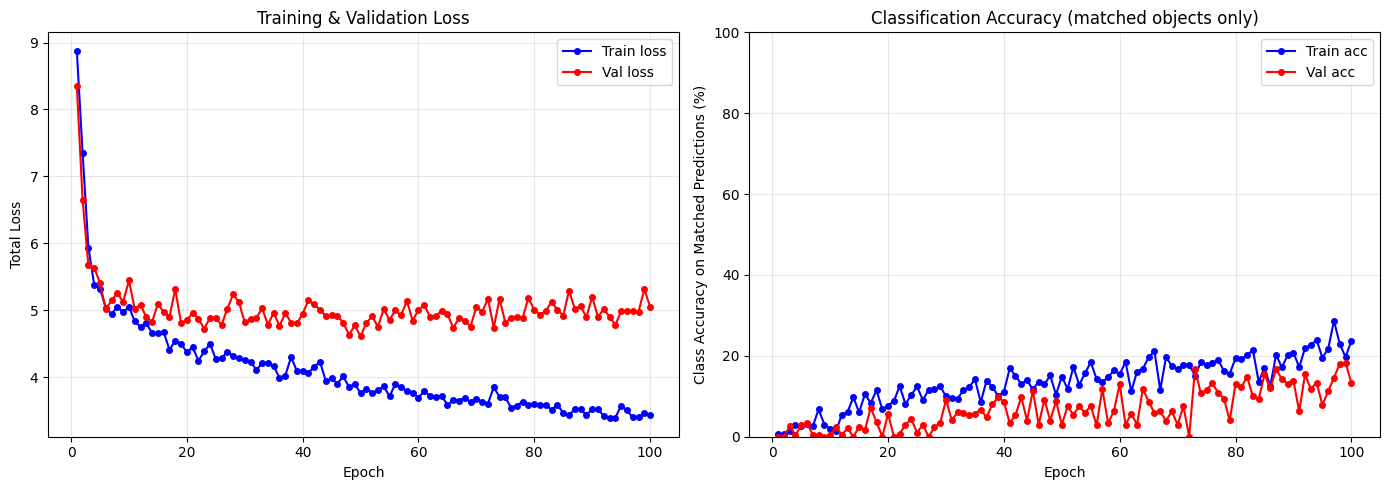

Best val loss: 4.6110


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)

# Loss plot
ax1.plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train loss')
ax1.plot(epochs, history['val_loss'],   'r-o', markersize=4, label='Val loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Total Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(epochs, [a * 100 for a in history['train_acc']], 'b-o', markersize=4, label='Train acc')
ax2.plot(epochs, [a * 100 for a in history['val_acc']],   'r-o', markersize=4, label='Val acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Class Accuracy on Matched Predictions (%)')
ax2.set_title('Classification Accuracy (matched objects only)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best val loss: {best_val_loss:.4f}")


## Step 10: Inference on a Single Image

Load the best checkpoint, run the model on one image, and visualise the
detected boxes with class labels and confidence scores.

In [12]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
model_inf = DETR(num_classes=NUM_CLASSES, num_queries=100, d_model=256,
                 num_encoder_layers=3, num_decoder_layers=3).to(device)
model_inf.load_state_dict(torch.load('detr_best.pth', map_location=device))
model_inf.eval()

# Reverse mapping: dense index → COCO category name
with open('coco_mini/annotations.json') as f:
    coco_ann = json.load(f)

cat_ids          = sorted({cat['id'] for cat in coco_ann['categories']})
cat_id_to_name   = {cat['id']: cat['name'] for cat in coco_ann['categories']}
idx_to_cat_name  = {i: cat_id_to_name[cid] for i, cid in enumerate(cat_ids)}
idx_to_cat_name[NUM_CLASSES] = 'background'

print(f"Loaded {NUM_CLASSES} classes. Category map sample:")
for k, v in list(idx_to_cat_name.items())[:5]:
    print(f"  {k}: {v}")


C:\Users\manin\AppData\Local\Temp\ipykernel_46176\1427311725.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_inf.load_state_dict(torch.load('detr_best.pth', map_lo

Loaded 80 classes. Category map sample:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane


Running inference on: coco_mini\images\000000397133.jpg


C:\Users\manin\AppData\Local\Temp\ipykernel_46176\1127443751.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', NUM_CLASSES)


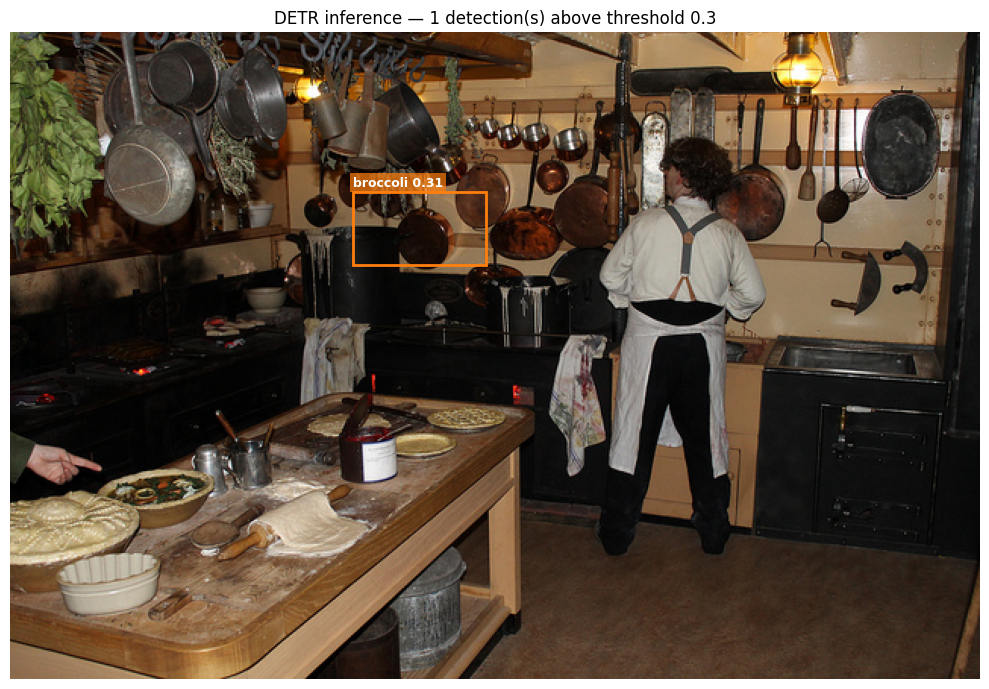

Detections: 1

Class                 Score
----------------------------
broccoli             0.313


In [13]:
def run_inference(image_path, model, threshold=0.5, img_size=IMG_SIZE):
    """
    Run DETR on a single image file and return a visualisation.

    threshold: minimum confidence score for a prediction to be shown.
    Any prediction where the model assigns probability < threshold to ALL
    real classes (i.e. it thinks it is background) is filtered out.
    """
    # ── Load and preprocess ───────────────────────────────────────────────────
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = image_rgb.shape[:2]

    # Resize to model input size
    scale    = img_size / max(orig_h, orig_w)
    new_h    = int(orig_h * scale)
    new_w    = int(orig_w * scale)
    resized  = cv2.resize(image_rgb, (new_w, new_h))

    tensor = torch.tensor(resized / 255.0, dtype=torch.float32).permute(2, 0, 1)
    tensor = (tensor - IMAGENET_MEAN) / IMAGENET_STD
    tensor = tensor.unsqueeze(0).to(device)

    # Mask: no padding for a single image (nothing is padded)
    mask = torch.zeros((1, new_h, new_w), dtype=torch.bool).to(device)

    # ── Forward pass ─────────────────────────────────────────────────────────
    with torch.no_grad():
        outputs = model(tensor, mask)

    probs = outputs['pred_logits'][0].softmax(-1)   # (Q, C+1)
    boxes = outputs['pred_boxes'][0]                  # (Q, 4)  — normalised cxcywh

    # ── Filter predictions ────────────────────────────────────────────────────
    # Keep any query where the max probability over REAL classes exceeds threshold
    max_scores, pred_classes = probs[:, :-1].max(-1)   # ignore background col
    keep = max_scores > threshold

    kept_boxes   = boxes[keep].cpu()
    kept_classes = pred_classes[keep].cpu()
    kept_scores  = max_scores[keep].cpu()

    # ── Visualise ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(image_rgb)

    colors = plt.cm.get_cmap('tab20', NUM_CLASSES)

    for box, cls_idx, score in zip(kept_boxes, kept_classes, kept_scores):
        cx, cy, w, h = box.tolist()

        # Convert normalised cxcywh → pixel xyxy in ORIGINAL image coordinates
        x1 = (cx - w / 2) * orig_w
        y1 = (cy - h / 2) * orig_h
        box_w = w * orig_w
        box_h = h * orig_h

        cls_name = idx_to_cat_name.get(cls_idx.item(), '?')
        color    = colors(cls_idx.item() % 20)

        rect = patches.Rectangle((x1, y1), box_w, box_h,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, max(y1 - 4, 0),
                f'{cls_name} {score:.2f}',
                color='white', fontsize=9, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.7, pad=2, edgecolor='none'))

    n = keep.sum().item()
    ax.set_title(f'DETR inference — {n} detection(s) above threshold {threshold}',
                 fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('inference_result.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Detections: {n}")
    return kept_boxes, kept_classes, kept_scores


# ── Run on the first image in the mini dataset ────────────────────────────────
sample_image_info = coco_ann['images'][0]
sample_path = os.path.join('coco_mini', 'images', sample_image_info['file_name'])
print(f"Running inference on: {sample_path}")

boxes_out, classes_out, scores_out = run_inference(sample_path, model_inf, threshold=0.3)

# Print detections in a table
print(f"\n{'Class':<20} {'Score':>6}")
print('-' * 28)
for cls, score in zip(classes_out, scores_out):
    print(f"{idx_to_cat_name.get(cls.item(), '?'):<20} {score.item():.3f}")


## Quick Sanity Check — Does the model output reasonable shapes?

Run this cell before training to verify the model is wired correctly.

In [14]:
_model_test = DETR(num_classes=NUM_CLASSES).to(device)
_x          = torch.randn(2, 3, 480, 480).to(device)
_m          = torch.zeros(2, 480, 480, dtype=torch.bool).to(device)

with torch.no_grad():
    _out = _model_test(_x, _m)

print('pred_logits shape:', _out['pred_logits'].shape)   # expect (2, 100, NUM_CLASSES+1)
print('pred_boxes  shape:', _out['pred_boxes'].shape)    # expect (2, 100, 4)
print('boxes range  :', _out['pred_boxes'].min().item(), '-', _out['pred_boxes'].max().item())
print('logits finite:', torch.isfinite(_out['pred_logits']).all().item())
del _model_test, _x, _m, _out


pred_logits shape: torch.Size([2, 100, 81])
pred_boxes  shape: torch.Size([2, 100, 4])
boxes range  : 0.45200321078300476 - 0.5529953241348267
logits finite: True
